In [1]:
import sys, os
# sys.stdout.reconfigure(line_buffering=True)
# sys.stderr.reconfigure(line_buffering=True)
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import jax
import jax.numpy as jnp
from jax.sharding import Mesh, PartitionSpec as P, NamedSharding
from jax.experimental import mesh_utils
import blackjax

jax.config.update("jax_enable_x64", True)
# NOTE: Disable debug_nans for production (incompatible with pathfinder/lax.while_loop)
# jax.config.update("jax_debug_nans", True)

import pathlib
import numpy as np
import yaml
import pickle as pk
import copy
import argparse
from scipy.interpolate import interp1d
from astropy.io import fits
from astropy import constants as const
from deepmerge import always_merger

# --- Path setup ---
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/")
abs_path_src = os.path.abspath(curr_path / "../../src/")
abs_path_results = os.path.abspath(curr_path / "../../results/")
abs_path_params = os.path.abspath(curr_path / "../../param_files/")
sys.path.append(str(curr_path))
sys.path.append(abs_path_data)
sys.path.append(abs_path_results)
sys.path.append(abs_path_src)

from get_Cls import get_Cl
import jax_cosmo.background as bkgrd
from jax_cosmo import Cosmology
from jax_cosmo.background import radial_comoving_distance

print(f"JAX devices: {jax.local_device_count()} local, {jax.device_count()} total")


JAX devices: 1 local, 1 total


In [2]:
probes_forecast = "ky,kk,gg,gy,gk,ge"
probes_forecast = probes_forecast.split(",")
sc_val = 8000

num_warmup = 100
num_samples = 200
num_chains= 16
max_tree_depth = 4
n_parallel = 1
beta_min = 0.1
wbao_prior = False
# num_pathfinder_draws = 200
target_accept = 0.8
# gtol_pf = 1e-4
# ftol_pf = 1e-4
# maxiter_pf = 10
model_matter = 'DMB'
use_parallel_tempering = (beta_min < 1.0)
# init_strategy = 'value'

num_devices = jax.local_device_count()

print(f"Config: probes={probes_forecast}, lmax={sc_val}, warmup={num_warmup}, "
      f"samples={num_samples}, chains={num_chains}, tree_depth={max_tree_depth}, "
      f"PT={'ON (beta_min=' + str(beta_min) + ')' if use_parallel_tempering else 'OFF'}")


Config: probes=['ky', 'kk', 'gg', 'gy', 'gk', 'ge'], lmax=8000, warmup=100, samples=200, chains=16, tree_depth=4, PT=ON (beta_min=0.1)


In [3]:
save_chain_dir = abs_path_results + '/pge/chains_july_v5/'
probes_forecast_all_str = '_'.join(probes_forecast)
os.makedirs(save_chain_dir + f'{probes_forecast_all_str}/', exist_ok=True)

savefname_out = (
    save_chain_dir + f'{probes_forecast_all_str}/'
    f'mcmc_v5_blackjax_{probes_forecast_all_str}_scval_{sc_val}'
    f'_samples_{num_samples}_warmup_{num_warmup}'
    f'_num_chains_{num_chains}_treedepth_{max_tree_depth}'
    f'_wbaoprior_{wbao_prior}'
    + ('_halofit' if model_matter == 'halofit' else '')
    + '.pkl'
)
print(f"Output: {savefname_out}")



Output: /mnt/ceph/users/spandey/paper_pge/GODMAX/results/pge/chains_july_v5/ky_kk_gg_gy_gk_ge/mcmc_v5_blackjax_ky_kk_gg_gy_gk_ge_scval_8000_samples_200_warmup_100_num_chains_16_treedepth_4_wbaoprior_False.pkl


In [4]:
# --- Load YAML configs ---
def read_yaml(file_path):
    with open(file_path, 'r') as f:
        return yaml.safe_load(f)

def generate_dicts(data):
    return (data.get('sim_params', {}), data.get('halo_params', {}),
            data.get('analysis', {}), data.get('other_params', {}))

default_data = read_yaml(abs_path_params + '/params_default.yaml')
if model_matter == 'halofit':
    new_data = read_yaml(abs_path_params + '/Pge/params_halofit.yaml')
else:
    new_data = read_yaml(abs_path_params + '/Pge/params.yaml')
merged_data = always_merger.merge(default_data, new_data)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

# --- Galaxy n(z) ---
df_nz_comoving = np.loadtxt(abs_path_data + '/pge/comoving_nz_bgs_lrg_DESIY3_key_zall.txt')
zarray_comoving = df_nz_comoving[:, 0]
nz_comoving = df_nz_comoving[:, 1].copy()
analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
analysis_dict['nbar_gal_comoving_val'] = nz_comoving

# --- Lens bins ---
ks = np.geomspace(3e-1, 10, 10)
zedges = np.array([0.1, 0.4, 0.6, 0.8, 1.1])
zarray_lens = np.linspace(0.001, 1.6, 100)
nbins_lens = len(zedges) - 1

cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
    Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
    Omega_b=cosmo_params['Ob0'],
    h=cosmo_params['H0'] / 100.,
    sigma8=cosmo_params['sigma8'],
    n_s=cosmo_params['ns'],
    Omega_k=0., w0=cosmo_params['w0'], wa=0.
)
scale_fac_a_array = 1.0 / (1.0 + zarray_lens)
chi_array = radial_comoving_distance(cosmo_jax, scale_fac_a_array)
dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo_jax, scale_fac_a_array)
nz_comoving_interp = interp1d(zarray_comoving, nz_comoving, fill_value=1e-20, bounds_error=False)
nz_comoving_zarray = nz_comoving_interp(zarray_lens)
nz_zarray = nz_comoving_zarray * (chi_array**2 * dchi_dz_array)
nz_zarray = nz_zarray / np.trapz(nz_zarray, zarray_lens)

nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb + 1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    nz_jb = nz_jb / np.trapz(nz_jb, zarray_lens)
    nz_lens[jb] = nz_jb

nz_info_dict = {'z_array_lens': zarray_lens, 'nbins_lens': nbins_lens}
for ji in range(nbins_lens):
    nz_info_dict['nz' + str(ji)] = np.maximum(nz_lens[ji], 1e-3)
analysis_dict['nz_lens_info_dict'] = nz_info_dict

# --- Source n(z) ---
df_fits = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array_source = df_fits['nz_source'].data['Z_MID']
nz_info_dict_s = {'z_array_source': z_array_source, 'nbins': 5}
for ji in range(5):
    nz_info_dict_s['nz' + str(ji)] = np.maximum(
        df_fits['nz_source'].data['BIN' + str(ji + 1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict_s

other_params_dict['Delta_z_bias_array'] = np.zeros(5)
other_params_dict['mult_shear_bias_array'] = np.zeros(5)
analysis_dict['angles_data_array'] = df_fits['xip'].data['ANG'][0:20]

# --- Survey arrays ---
analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0'] / 100.))
lmin, lmax_ell, dl_log = 80.0, 8800.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax_ell), dl_log))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)
analysis_dict['yy_noise_ell_fname'] = os.path.abspath(
    abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')

# --- Galaxy number densities per bin ---
Ngals_bins = []
P0 = 9e3
fsky_gg = analysis_dict['fsky_gg']
for jb in range(nbins_lens):
    nz_jb_only = np.copy(nz_comoving_zarray)
    indsel = np.where((zarray_lens < zedges[jb]) | (zarray_lens > zedges[jb + 1]))[0]
    nz_jb_only[indsel] = 0.0
    nz_integrate = np.trapz(nz_jb_only * (chi_array**2) * dchi_dz_array, zarray_lens)
    Ngals_bins.append(nz_integrate * 4 * np.pi * fsky_gg)
Ngals_bins = np.array(Ngals_bins)
analysis_dict['nbar_lens_bins'] = Ngals_bins / (fsky_gg * 41253 * (60**2))
analysis_dict['symbolic_pk'] = True
analysis_dict['symbolic_hmf'] = True



In [5]:
# --- Fiducial data vector & covariance ---
df_dv = pk.load(open(
    abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod_v6_symb_dataconsist.pk', 'rb'))
probes_all = df_dv['probes']
ell_edges_left = df_dv['edges_left']
ell_edges_right = df_dv['edges_right']
ell_array = df_dv['ell_array']
k_array = df_dv['k_array']
bin_comb_all_wprobe = df_dv['bin_comb_all_wprobe']
cov_total_orig = df_dv['cov_mat']
cov_total_orig_scaled = df_dv['cov_mat_scaled']
Cl_total_scaled = df_dv['dv_scaled']
scale_vec = jnp.array(df_dv['scale_vec'])


In [6]:
nell = len(ell_array)
nk = len(analysis_dict['k_array_survey'])
dv_size = cov_total_orig.shape[0]
edge_left_pge = ell_edges_left[-1]

# --- Scale cuts ---
ell_sel_min, ell_sel_max = [], []
for jp in range(len(probes_forecast)):
    indp = probes_all.index(probes_forecast[jp])
    ell_sel_min.append(ell_edges_left[indp])
    ell_sel_max.append(ell_edges_right[indp])

ell_sel_min = np.array(ell_sel_min)
ell_sel_max = np.array(ell_sel_max)
argsort_min = np.argsort(ell_sel_min)
probes_forecast = [probes_forecast[jp] for jp in argsort_min]
ell_sel_min = ell_sel_min[argsort_min]
ell_sel_max = ell_sel_max[argsort_min]

fname_sc = abs_path_data + f'/pge/scale_cuts_all_probes_ellmax_{sc_val}.yaml'
with open(fname_sc, 'r') as stream:
    sc_all = yaml.load(stream, Loader=yaml.SafeLoader)

ell_sel_all = []
for jp in range(len(probes_forecast)):
    probe = probes_forecast[jp]
    sc_all_jp = sc_all[probe]
    ell_min_jp = ell_sel_min[jp]
    if probe != 'ge':
        for jsc in range(len(sc_all_jp)):
            key = list(sc_all_jp.keys())[jsc]
            scmin, scmax = sc_all_jp[key][0], sc_all_jp[key][1]
            indsel = np.where((ell_array >= scmin) & (ell_array <= scmax))[0]
            if len(indsel) > 0:
                ell_sel_all.append(
                    np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1] + 1))
            ell_min_jp += nell
    else:
        for jsc in range(len(sc_all_jp)):
            key = list(sc_all_jp.keys())[jsc]
            scmin, scmax = sc_all_jp[key][0], sc_all_jp[key][1]
            indsel = np.where((k_array >= scmin) & (k_array <= scmax))[0]
            ell_sel_all.append(
                np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1] + 1))
            ell_min_jp += nk
ell_sel_all = np.concatenate(ell_sel_all)

data_vec = jnp.array(Cl_total_scaled[ell_sel_all])
cov_total = cov_total_orig_scaled[ell_sel_all, :][:, ell_sel_all]
inv_cov = jnp.linalg.inv(cov_total)

print(f"Data vector: {data_vec.shape[0]} elements")


Data vector: 988 elements


In [7]:
# ============================================================================
# SECTION 3: PRIOR SETUP & PARAMETER INDEXING
# ============================================================================

# --- Load priors ---
if wbao_prior:
    prior_data = read_yaml(abs_path_params + '/Pge/priors_bao.yaml')
else:
    prior_data = read_yaml(abs_path_params + '/Pge/priors.yaml')

prior_limits = {k: tuple(map(float, v.split())) for k, v in prior_data['prior_uniform'].items()}
prior_gaussian = {k: tuple(map(float, v.split())) for k, v in prior_data['prior_gaussian'].items()}

prior_min_all_dict = {k: v[0] for k, v in prior_limits.items()}
prior_max_all_dict = {k: v[1] for k, v in prior_limits.items()}
prior_mu_all_dict = {k: v[0] for k, v in prior_gaussian.items()}
prior_sig_all_dict = {k: v[1] for k, v in prior_gaussian.items()}

# Gaussian prior arrays
prior_delta_z_mu = jnp.array([prior_mu_all_dict[f'Delta_z_bias_bin{i+1}'] for i in range(5)])
prior_delta_z_sig = jnp.array([prior_sig_all_dict[f'Delta_z_bias_bin{i+1}'] for i in range(5)])
prior_mult_shear_mu = jnp.array([prior_mu_all_dict[f'mult_shear_bias_bin{i+1}'] for i in range(5)])
prior_mult_shear_sig = jnp.array([prior_sig_all_dict[f'mult_shear_bias_bin{i+1}'] for i in range(5)])

# --- Parameter ordering in z_vector ---
#   [0:5]   cosmo:   Om0, sigma8, Ob0, h, ns
#   [5:10]  baryons: theta_ej_0, nu_theta_ej_z, nu_theta_ej_M, mu_beta, alpha_nt
#   [10:18] gals:    log10M1_fshmr, log10M1_a_fshmr, gamma_fshmr, gamma_a_fshmr,
#                    delta_fshmr, delta_a_fshmr, siglogMstar_Ncen, alphasat_Nsat
#   [18:20] IA:      A_IA, eta_IA
#   [20:25] Delta_z_bias (5 bins, Gaussian)
#   [25:30] mult_shear_bias (5 bins, Gaussian)

cosmo_params_vary_names = ['Om0', 'sigma8', 'Ob0', 'h', 'ns']
sims_params_vary_names_baryons = [
    'theta_ej_0', 'nu_theta_ej_z', 'nu_theta_ej_M', 'mu_beta', 'alpha_nt']
sims_params_vary_names_gals = [
    'log10M1_fshmr', 'log10M1_a_fshmr', 'gamma_fshmr', 'gamma_a_fshmr',
    'delta_fshmr', 'delta_a_fshmr', 'siglogMstar_Ncen', 'alphasat_Nsat']
sims_params_vary_names = sims_params_vary_names_baryons + sims_params_vary_names_gals
IA_params_vary_names = ['A_IA', 'eta_IA']

uniform_param_names = cosmo_params_vary_names + sims_params_vary_names + IA_params_vary_names
n_uniform = len(uniform_param_names)    # 20
n_delta_z = 5
n_mult_shear = 5
n_gaussian = n_delta_z + n_mult_shear   # 10
TOTAL_DIM = n_uniform + n_gaussian      # 30
n_cosmo = len(cosmo_params_vary_names)  # 5
n_sims = len(sims_params_vary_names)    # 13

# Prior bounds as JAX arrays for vectorized CDF mapping
uniform_min = jnp.array([prior_min_all_dict[name] for name in uniform_param_names])
uniform_max = jnp.array([prior_max_all_dict[name] for name in uniform_param_names])

# BAO prior on Om0 (Gaussian instead of Uniform when enabled)
bao_Om0_mu = prior_mu_all_dict.get('Om0', 0.3)
bao_Om0_sig = prior_sig_all_dict.get('Om0', 0.01)

print(f"Parameter space: {TOTAL_DIM}D ({n_uniform} uniform + {n_gaussian} gaussian)")


Parameter space: 30D (20 uniform + 10 gaussian)


In [8]:
# ============================================================================
# SECTION 4: LOG DENSITY FUNCTION (pure JAX, JIT-compatible)
# ============================================================================
@jax.jit
def log_density(z_vector):
    """
    Log posterior in the unit-normal reparameterized space.

    z_vector: shape (TOTAL_DIM,), each entry drawn from N(0,1).

    Reparameterization:
      Uniform priors  -> physical = min + (max - min) * Phi(z)   [Phi = std normal CDF]
      Gaussian priors -> physical = mu  + sigma * z              [decentering]

    Returns scalar: log_prior + log_likelihood.
    """
    # --- Log prior (standard normal in z-space) ---
    log_prior = jnp.sum(jax.scipy.stats.norm.logpdf(z_vector))

    # --- Map z -> physical parameters ---
    z_uniform = z_vector[:n_uniform]
    physical_uniform = uniform_min + (uniform_max - uniform_min) * jax.scipy.special.ndtr(z_uniform)

    # Override Om0 with Gaussian mapping if BAO prior is active
    if wbao_prior:
        physical_uniform = physical_uniform.at[0].set(bao_Om0_mu + bao_Om0_sig * z_vector[0])

    # Gaussian-prior parameters
    delta_z_bias = prior_delta_z_mu + prior_delta_z_sig * z_vector[n_uniform:n_uniform + n_delta_z]
    mult_shear_bias = (prior_mult_shear_mu
                       + prior_mult_shear_sig * z_vector[n_uniform + n_delta_z:TOTAL_DIM])

    # --- Build sim_params_dict_vary ---
    sim_params_dict_vary = dict(sim_params_dict)
    sim_params_dict_vary['cosmo'] = dict(sim_params_dict['cosmo'])

    # Cosmological parameters
    sim_params_dict_vary['cosmo']['Om0'] = physical_uniform[0]
    sim_params_dict_vary['cosmo']['sigma8'] = physical_uniform[1]
    sim_params_dict_vary['cosmo']['Ob0'] = physical_uniform[2]
    sim_params_dict_vary['cosmo']['H0'] = 100.0 * physical_uniform[3]  # h -> H0
    sim_params_dict_vary['cosmo']['ns'] = physical_uniform[4]

    # Baryon + galaxy parameters
    for jp, name in enumerate(sims_params_vary_names):
        sim_params_dict_vary[name] = physical_uniform[n_cosmo + jp]

    # --- Build other_params_dict_vary ---
    other_params_dict_vary = dict(other_params_dict)
    other_params_dict_vary['A_IA'] = physical_uniform[n_cosmo + n_sims]      # index 18
    other_params_dict_vary['eta_IA'] = physical_uniform[n_cosmo + n_sims + 1] # index 19
    other_params_dict_vary['Delta_z_bias_array'] = delta_z_bias
    other_params_dict_vary['mult_shear_bias_array'] = mult_shear_bias

    # --- Compute theory Cls ---
    model_obj = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)

    # Assemble full data vector (same ordering as fiducial)
    Cl_all = jnp.zeros(dv_size)
    for jp1 in range(len(bin_comb_all_wprobe)):
        probe1, bin_comb1 = bin_comb_all_wprobe[jp1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'ky':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(
                model_obj.Cl_kappa_y_tot_mat[:, b1-1])
        elif probe1 == 'kk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(
                model_obj.Cl_kappa_kappa_tot_mat[:, b1-1, b2-1])
        elif probe1 == 'gg':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(
                model_obj.Cl_gal_gal_tot_mat[:, b1-1, b2-1])
        elif probe1 == 'gk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(
                model_obj.Cl_gal_kappa_tot_mat[:, b1-1, b2-1])
        elif probe1 == 'gy':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(
                model_obj.Cl_gal_y_tot_mat[:, b1-1])

    for jb in range(nbins_lens):
        Cl_all = Cl_all.at[edge_left_pge + jb*nk : edge_left_pge + (jb+1)*nk].set(
            model_obj.Pge_tot_mat[jb, :])

    Cl_all = Cl_all * scale_vec
    mu = Cl_all[ell_sel_all]

    # --- Log likelihood: -0.5 * (data - mu)^T @ inv_cov @ (data - mu) ---
    residual = data_vec - mu
    log_lik = -0.5 * residual @ inv_cov @ residual

    return log_prior + log_lik



In [9]:
# ============================================================================
# SECTION 5: PT-NUTS HELPER FUNCTIONS
# ============================================================================

def pt_swap_step(rng_key, states, betas):
    """
    Even-odd parallel tempering swap between adjacent temperature chains.

    After local NUTS moves, propose position swaps between adjacent (i, i+1)
    pairs. Accept with Metropolis-Hastings ratio:
        log_alpha = (beta_i - beta_{i+1}) * (ld(x_{i+1}) - ld(x_i))
    where ld is the UNTEMPERED log density.

    States are updated in-place: positions, logdensity, and logdensity_grad
    are swapped and rescaled to the new temperature.
    """
    even_key, odd_key = jax.random.split(rng_key)
    states = _swap_pairs(even_key, states, betas, start=0)
    states = _swap_pairs(odd_key, states, betas, start=1)
    return states


def _swap_pairs(rng_key, states, betas, start):
    """Propose swaps for pairs starting at index `start` (0=even, 1=odd)."""
    n = betas.shape[0]
    i_idx = jnp.arange(start, n - 1, 2)
    j_idx = i_idx + 1
    n_pairs = i_idx.shape[0]

    # Untempered log densities (tempered_ld = beta * untempered_ld)
    untempered_ld = states.logdensity / betas

    # Acceptance criterion
    log_alpha = ((betas[i_idx] - betas[j_idx])
                 * (untempered_ld[j_idx] - untempered_ld[i_idx]))
    u = jax.random.uniform(rng_key, shape=(n_pairs,))
    do_swap = jnp.log(u) < log_alpha

    # --- Swap positions ---
    pos = states.position
    new_pos_i = jnp.where(do_swap[:, None], pos[j_idx], pos[i_idx])
    new_pos_j = jnp.where(do_swap[:, None], pos[i_idx], pos[j_idx])
    new_pos = pos.at[i_idx].set(new_pos_i).at[j_idx].set(new_pos_j)

    # --- Swap and rescale logdensity ---
    ld = states.logdensity
    # After swap, chain i gets x_j: tempered_ld = beta_i * untempered_ld(x_j)
    new_ld_i = jnp.where(do_swap, (betas[i_idx] / betas[j_idx]) * ld[j_idx], ld[i_idx])
    new_ld_j = jnp.where(do_swap, (betas[j_idx] / betas[i_idx]) * ld[i_idx], ld[j_idx])
    new_ld = ld.at[i_idx].set(new_ld_i).at[j_idx].set(new_ld_j)

    # --- Swap and rescale logdensity_grad ---
    grad = states.logdensity_grad
    ratio_ij = (betas[i_idx] / betas[j_idx])[:, None]
    ratio_ji = (betas[j_idx] / betas[i_idx])[:, None]
    new_grad_i = jnp.where(do_swap[:, None], grad[j_idx] * ratio_ij, grad[i_idx])
    new_grad_j = jnp.where(do_swap[:, None], grad[i_idx] * ratio_ji, grad[j_idx])
    new_grad = grad.at[i_idx].set(new_grad_i).at[j_idx].set(new_grad_j)

    return states._replace(position=new_pos, logdensity=new_ld, logdensity_grad=new_grad)

In [10]:
# # ============================================================================
# # SECTION 6: SAMPLING ENGINE
# # ============================================================================

# def run_sampling(rng_key):
#     """
#     Full sampling pipeline:
#       1. Pathfinder   -> initial position + dense mass matrix
#       2. Warmup       -> adapted step size (via window adaptation)
#       3. PT-NUTS loop -> production samples with optional parallel tempering
#     """
#     pf_key, warmup_key, sample_key = jax.random.split(rng_key, 3)

#     # ------------------------------------------------------------------
#     # STEP 1: PATHFINDER INITIALIZATION
#     # ------------------------------------------------------------------
#     print("Step 1/3: Running Pathfinder for initialization + dense mass matrix...")
#     z_init = jnp.zeros(TOTAL_DIM)  # Origin of z-space = prior medians

#     pf_state, pf_info = blackjax.pathfinder.approximate(
#         pf_key, log_density, z_init, num_samples=num_pathfinder_draws, maxiter=maxiter_pf, gtol=gtol_pf, ftol=ftol_pf)

#     # Best sample from pathfinder as starting point
#     best_idx = jnp.argmax(pf_state.logdensity)
#     initial_position = pf_state.position[best_idx]

#     # Dense inverse mass matrix from pathfinder (approx inverse Hessian)
#     inv_mass_matrix = pf_info.inverse_mass_matrix
#     print(f"  Pathfinder done. Best log-density: {pf_state.logdensity[best_idx]:.2f}")

#     # ------------------------------------------------------------------
#     # STEP 2: WARMUP (Window Adaptation for step size)
#     # ------------------------------------------------------------------
#     print("Step 2/3: Running window adaptation warmup...")
#     warmup = blackjax.window_adaptation(
#         blackjax.nuts,
#         log_density,
#         target_acceptance_rate=target_accept,
#         is_mass_matrix_diagonal=False,
#         initial_step_size=1e-3,
#         max_num_doublings=max_tree_depth,
#     )
#     (warmup_state, warmup_params), warmup_info = warmup.run(
#         warmup_key, initial_position, num_steps=num_warmup)

#     step_size = warmup_params['step_size']
#     inv_mass_matrix = warmup_params['inverse_mass_matrix']
#     print(f"  Warmup done. Adapted step size: {step_size:.6f}")

#     # ------------------------------------------------------------------
#     # STEP 3: PT-NUTS PRODUCTION SAMPLING
#     # ------------------------------------------------------------------
#     print(f"Step 3/3: Sampling {num_samples} steps x {num_chains} chains...")

#     # Temperature ladder (beta=1 is the target distribution)
#     betas = jnp.geomspace(beta_min, 1.0, num_chains) if use_parallel_tempering \
#         else jnp.ones(num_chains)

#     # Initialize all chains from the warmup position (with small jitter)
#     init_key, loop_key = jax.random.split(sample_key)
#     init_keys = jax.random.split(init_key, num_chains)
#     jitter = jax.vmap(lambda k: jax.random.normal(k, shape=(TOTAL_DIM,)) * 0.01)(init_keys)
#     init_positions = warmup_state.position + jitter  # (num_chains, TOTAL_DIM)

#     # Create NUTS kernel for each temperature
#     # We define a batched step function that vmaps over (beta, key, state)
#     def single_chain_step(beta, rng_key, state):
#         """One NUTS step at inverse temperature beta."""
#         tempered_ld = lambda z: beta * log_density(z)
#         kernel = blackjax.nuts(
#             tempered_ld,
#             step_size=step_size,
#             inverse_mass_matrix=inv_mass_matrix,
#             max_num_doublings=max_tree_depth,
#         )
#         return kernel.step(rng_key, state)

#     batched_step = jax.vmap(single_chain_step, in_axes=(0, 0, 0))

#     # Initialize NUTS states for all chains
#     def init_single(beta, position):
#         tempered_ld = lambda z: beta * log_density(z)
#         return blackjax.nuts.init(position, tempered_ld)

#     init_states = jax.vmap(init_single, in_axes=(0, 0))(betas, init_positions)

#     # Shard states across GPUs
#     devices = mesh_utils.create_device_mesh((num_devices,))
#     mesh = Mesh(devices, axis_names=('chains',))
#     chain_sharding = NamedSharding(mesh, P('chains'))
#     init_states = jax.device_put(init_states, chain_sharding)
#     betas = jax.device_put(betas, chain_sharding)

#     # --- Sampling loop via lax.scan ---
#     @jax.jit
#     def scan_step(carry, _):
#         rng_key, states = carry
#         rng_key, step_key, swap_key = jax.random.split(rng_key, 3)

#         # Local NUTS moves (vmapped across chains/GPUs)
#         step_keys = jax.random.split(step_key, num_chains)
#         new_states, infos = batched_step(betas, step_keys, states)

#         # Parallel tempering swaps (if enabled)
#         if use_parallel_tempering:
#             new_states = pt_swap_step(swap_key, new_states, betas)

#         # Collect: position of coldest chain (beta=1, last index) + all acceptance rates
#         cold_chain_pos = new_states.position[-1]
#         accept_rates = infos.acceptance_rate

#         return (rng_key, new_states), (cold_chain_pos, accept_rates)

#     # Run the scan
#     print(f"  Running on {num_devices} GPU(s) with {'PT' if use_parallel_tempering else 'standard'} NUTS...")
#     (_, final_states), (all_positions, all_accept_rates) = jax.lax.scan(
#         scan_step,
#         (loop_key, init_states),
#         jnp.arange(num_samples),
#     )
#     # all_positions: (num_samples, TOTAL_DIM) -- cold chain only
#     # all_accept_rates: (num_samples, num_chains)

#     return all_positions, all_accept_rates, betas


In [11]:
# ============================================================================
# SECTION 6: SAMPLING ENGINE
# ============================================================================

def run_sampling(rng_key):
    """
    Full sampling pipeline (Memory-efficient version without Pathfinder):
      1. Parallel multi-chain warmup -> find best initialization + adapted parameters
      2. PT-NUTS loop                -> production samples with optional parallel tempering
    
    Strategy: Run multiple warmup chains from dispersed initial positions,
    assess their quality (log density), then use the best chain's final state 
    and adapted parameters to initialize production sampling.
    """
    warmup_key, sample_key = jax.random.split(rng_key, 2)

    # ------------------------------------------------------------------
    # STEP 1: PARALLEL MULTI-CHAIN WARMUP
    # ------------------------------------------------------------------
    num_warmup_chains = num_chains  # Run multiple chains to find good initialization
    use_dense_mass = True  # Set to False for diagonal (more memory efficient)
    num_warmup_steps = num_warmup  # Use same warmup length as before

    print(f"Step 1/2: Running {num_warmup_chains} parallel warmup chains...")
    print(f"  Warmup steps per chain: {num_warmup_steps}")
    print(f"  Mass matrix: {'dense' if use_dense_mass else 'diagonal'}")

    # Initialize chains from dispersed positions
    # Start from origin (prior medians in z-space) with random perturbations
    warmup_init_keys = jax.random.split(warmup_key, num_warmup_chains + 1)
    init_positions_key, warmup_init_keys = warmup_init_keys[0], warmup_init_keys[1:]

    # Create diverse starting positions: origin + random normal perturbations
    init_positions = jax.vmap(
        lambda k: jax.random.normal(k, shape=(TOTAL_DIM,)) * 0.5
    )(jax.random.split(init_positions_key, num_warmup_chains))

    # Run window adaptation for each chain in parallel
    def run_single_warmup(key, init_pos):
        """Run warmup for a single chain and return quality metrics."""
        warmup = blackjax.window_adaptation(
            blackjax.nuts,
            log_density,
            target_acceptance_rate=target_accept,
            is_mass_matrix_diagonal=(not use_dense_mass),
            initial_step_size=1e-3,
            max_num_doublings=max_tree_depth,
        )
        (state, params), info = warmup.run(key, init_pos, num_steps=num_warmup_steps)

        # Quality metric: final log density (higher = better)
        final_logdensity = log_density(state.position)
        
        return state, params, final_logdensity

    # Vectorize across warmup chains
    print("  Running warmup chains in parallel...")
    all_states, all_params, all_logdensities = jax.vmap(
        run_single_warmup
    )(warmup_init_keys, init_positions)

    # Select best chain based on final log density
    best_chain_idx = jnp.argmax(all_logdensities)

    # Extract best chain's results
    warmup_state = jax.tree_map(lambda x: x[best_chain_idx], all_states)
    warmup_params = jax.tree_map(lambda x: x[best_chain_idx], all_params)

    print(f"\n  Warmup complete. Selected chain #{best_chain_idx} (highest log density):")
    print(f"    Log density: {all_logdensities[best_chain_idx]:.2f}")
    print(f"    Adapted step size: {warmup_params['step_size']:.6f}")
    print(f"\n  Quality distribution across {num_warmup_chains} warmup chains:")
    print(f"    Log density range: [{jnp.min(all_logdensities):.2f}, {jnp.max(all_logdensities):.2f}]")
    print(f"    Log density std:   {jnp.std(all_logdensities):.2f}")

    step_size = warmup_params['step_size']
    inv_mass_matrix = warmup_params['inverse_mass_matrix']

    # ------------------------------------------------------------------
    # STEP 2: PT-NUTS PRODUCTION SAMPLING
    # ------------------------------------------------------------------
    print(f"\nStep 2/2: Sampling {num_samples} steps x {num_chains} chains...")

    # Temperature ladder (beta=1 is the target distribution)
    betas = jnp.geomspace(beta_min, 1.0, num_chains) if use_parallel_tempering \
        else jnp.ones(num_chains)

    # Initialize all chains from the best warmup position (with small jitter)
    init_key, loop_key = jax.random.split(sample_key)
    init_keys = jax.random.split(init_key, num_chains)
    jitter = jax.vmap(lambda k: jax.random.normal(k, shape=(TOTAL_DIM,)) * 0.01)(init_keys)
    init_positions = warmup_state.position + jitter  # (num_chains, TOTAL_DIM)

    # Create NUTS kernel for each temperature
    def single_chain_step(beta, rng_key, state):
        """One NUTS step at inverse temperature beta."""
        tempered_ld = lambda z: beta * log_density(z)
        kernel = blackjax.nuts(
            tempered_ld,
            step_size=step_size,
            inverse_mass_matrix=inv_mass_matrix,
            max_num_doublings=max_tree_depth,
        )
        return kernel.step(rng_key, state)

    batched_step = jax.vmap(single_chain_step, in_axes=(0, 0, 0))

    # Initialize NUTS states for all chains
    def init_single(beta, position):
        tempered_ld = lambda z: beta * log_density(z)
        return blackjax.nuts.init(position, tempered_ld)

    init_states = jax.vmap(init_single, in_axes=(0, 0))(betas, init_positions)

    # Shard states across GPUs
    devices = mesh_utils.create_device_mesh((num_devices,))
    mesh = Mesh(devices, axis_names=('chains',))
    chain_sharding = NamedSharding(mesh, P('chains'))
    init_states = jax.device_put(init_states, chain_sharding)
    betas = jax.device_put(betas, chain_sharding)

    # --- Sampling loop via lax.scan ---
    @jax.jit
    def scan_step(carry, _):
        rng_key, states = carry
        rng_key, step_key, swap_key = jax.random.split(rng_key, 3)

        # Local NUTS moves (vmapped across chains/GPUs)
        step_keys = jax.random.split(step_key, num_chains)
        new_states, infos = batched_step(betas, step_keys, states)

        # Parallel tempering swaps (if enabled)
        if use_parallel_tempering:
            new_states = pt_swap_step(swap_key, new_states, betas)

        # Collect: position of coldest chain (beta=1, last index) + all acceptance rates
        cold_chain_pos = new_states.position[-1]
        accept_rates = infos.acceptance_rate

        return (rng_key, new_states), (cold_chain_pos, accept_rates)

    # Run the scan
    print(f"  Running on {num_devices} GPU(s) with {'PT' if use_parallel_tempering else 'standard'} NUTS...")
    (_, final_states), (all_positions, all_accept_rates) = jax.lax.scan(
        scan_step,
        (loop_key, init_states),
        jnp.arange(num_samples),
    )
    # all_positions: (num_samples, TOTAL_DIM) -- cold chain only
    # all_accept_rates: (num_samples, num_chains)

    return all_positions, all_accept_rates, betas

# ============================================================================
# SECTION 7: MAIN EXECUTION
# ============================================================================
print("\n" + "=" * 60)
print("Starting BlackJax sampling pipeline")
print("=" * 60 + "\n")

rng_key = jax.random.PRNGKey(42)
all_positions, all_accept_rates, betas = run_sampling(rng_key)

all_positions.shape





Starting BlackJax sampling pipeline

Step 1/2: Running 16 parallel warmup chains...
  Warmup steps per chain: 100
  Mass matrix: dense
  Running warmup chains in parallel...


/tmp/ipykernel_1296843/3910083293.py:66: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  warmup_state = jax.tree_map(lambda x: x[best_chain_idx], all_states)



  Warmup complete. Selected chain #15 (highest log density):
    Log density: -5830.83
    Adapted step size: 0.002594

  Quality distribution across 16 warmup chains:
    Log density range: [-45962917.28, -5830.83]
    Log density std:   14309876.66

Step 2/2: Sampling 200 steps x 16 chains...
  Running on 1 GPU(s) with PT NUTS...


(200, 30)

In [12]:
# Map z-space samples back to physical parameter space
print("\nMapping samples to physical parameter space...")
physical_uniform_all = uniform_min + (uniform_max - uniform_min) * jax.scipy.special.ndtr(
    all_positions[:, :n_uniform])
if wbao_prior:
    physical_uniform_all = physical_uniform_all.at[:, 0].set(
        bao_Om0_mu + bao_Om0_sig * all_positions[:, 0])

delta_z_all = prior_delta_z_mu + prior_delta_z_sig * all_positions[:, n_uniform:n_uniform + n_delta_z]
mult_shear_all = (prior_mult_shear_mu
                  + prior_mult_shear_sig * all_positions[:, n_uniform + n_delta_z:TOTAL_DIM])


# ============================================================================
# SECTION 8: SAVE RESULTS
# ============================================================================

# Build trace dict (same format as numpyro version for compatibility)
trace = {}

# Uniform parameters
for jp, name in enumerate(uniform_param_names):
    if name == 'h':
        trace['h'] = np.array(physical_uniform_all[:, jp])
    else:
        trace[name] = np.array(physical_uniform_all[:, jp])

# Gaussian parameters
trace['Delta_z_bias_array'] = np.array(delta_z_all)
trace['mult_shear_bias_array'] = np.array(mult_shear_all)

# Diagnostics
trace['accept_prob'] = np.array(all_accept_rates)
trace['z_space_samples'] = np.array(all_positions)

# Run settings (for reproducibility)
trace['RUN_SETTINGS'] = {
    'prior_min': prior_min_all_dict,
    'prior_max': prior_max_all_dict,
    'fiducial_sims_params': sim_params_dict,
    'fiducial_other_params': other_params_dict,
    'fiducial_halo_params': halo_params_dict,
    'fiducial_analysis_params': analysis_dict,
    'sampler': 'blackjax_pt_nuts',
    'num_warmup': num_warmup,
    'num_samples': num_samples,
    'num_chains': num_chains,
    'max_tree_depth': max_tree_depth,
    'beta_min': beta_min,
    'betas': np.array(betas),
    'target_accept': target_accept,
    'uniform_param_names': uniform_param_names,
    'total_dim': TOTAL_DIM,
}




Mapping samples to physical parameter space...


In [18]:
import pickle as pk
trace = pk.load(open('/mnt/ceph/users/spandey/paper_pge/GODMAX/results/pge/chains_july_v6/kk_gg_gk/mcmc_v6_blackjax_kk_gg_gk_scval_2000_samples_6000_warmup_6000_num_chains_24_treedepth_4_wbaoprior_False_halofit.pkl','rb'))

trace_np = pk.load(open('/mnt/ceph/users/spandey/paper_pge/GODMAX/results/pge/chains_july_v6/kk_gg_gk/mcmc_v6_kk_gg_gk_scval_2000_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_False_halofit.pkl','rb'))

# df['s'].shape
# trace = df['trace']


In [6]:
trace.keys()


dict_keys(['Om0', 'sigma8', 'Ob0', 'h', 'ns', 'theta_ej_0', 'nu_theta_ej_z', 'nu_theta_ej_M', 'mu_beta', 'alpha_nt', 'log10M1_fshmr', 'log10M1_a_fshmr', 'gamma_fshmr', 'gamma_a_fshmr', 'delta_fshmr', 'delta_a_fshmr', 'siglogMstar_Ncen', 'alphasat_Nsat', 'A_IA', 'eta_IA', 'Delta_z_bias_array', 'mult_shear_bias_array', 'accept_prob', 'z_space_samples', 'RUN_SETTINGS'])

In [19]:
import pickle as pk
# df = pk.load(open('/mnt/home/spandey/ceph/GODMAX/notebooks/ACTxDES/mcmc_gty_xip_xim_8000_8000_800.pkl','rb'))
# df['s'].shape
# df
samps = []
samps_np = []
keys = []
samps_all_dict = trace
for key in samps_all_dict:
    # if ('base' not in key) and ('decentered' not in key) and ('log' not in key) and ('_log' not in key):
    if ('Delta_z_bias_array' not in key) and ('mult_shear_bias_array' not in key) and ('accept_prob' not in key) and ('z_space_samples' not in key) and ('RUN_SETTINGS' not in key):        
        # print(key, samps_all_dict[key].shape, len(samps_all_dict[key].shape))
        if len(samps) == 0:
            samps = samps_all_dict[key][:, None]
            samps_np = samps_all_dict[key][:, None]
        else:
            if len(samps_all_dict[key].shape) > 1:
                samps = np.concatenate((samps, samps_all_dict[key]), axis=1)
                samps_np = np.concatenate((samps_np, samps_all_dict[key]), axis=1)
            else:
                samps = np.concatenate((samps, samps_all_dict[key][:, None]), axis=1)
                samps_np = np.concatenate((samps_np, samps_all_dict[key][:, None]), axis=1)
        if 'array' in key:
            for jb in range(samps_all_dict[key].shape[1]):
                keys.append(key + str(jb))
        else:
            keys.append(key)
samps = np.array(samps)
samps_np = np.array(samps_np)


In [20]:
# energy.shape



In [21]:
# import matplotlib.pyplot as plt
# # samps.shape, len(keys)
# extra_fields = mcmc.get_extra_fields()
# energy = extra_fields['potential_energy']
# # reshape to shape: (num_samples, num_chains)
# energy = energy.reshape(n_vectorized, num_samples)
# # energy = energy.reshape(num_samples, n_vectorized)
# for chain in range(energy.shape[0]):
#     plt.figure()
#     plt.plot(energy[chain,:])
#     # plt.plot(energy[:, chain])    
#     plt.title(f'Potential Energy: Chain {chain}')
#     plt.xlabel('Iteration')
#     plt.ylabel('Potential Energy')
#     plt.show()



In [22]:
import matplotlib.pyplot as plt
%matplotlib inline


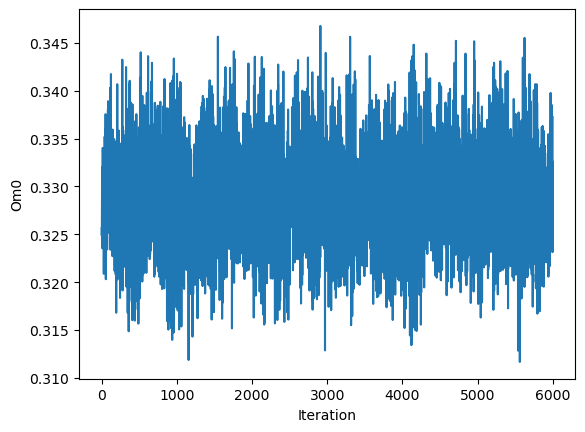

In [11]:
param = 'Om0'  # pick a key from samples
vals = samps_all_dict[param]  # shape: (num_samples, num_chains, ...)

plt.figure()
# plt.plot(vals[chain,:])
plt.plot(vals)    
# plt.title(f'Potential Energy: Chain {chain}')
plt.xlabel('Iteration')
plt.ylabel(param)
plt.show()


# vals = vals.reshape(n_vectorized, num_samples)
# vals = vals.reshape(num_samples, n_vectorized)
# energy = energy.reshape(num_samples, n_vectorized)
# for chain in range(vals.shape[0]):
# for chain in range(vals.shape[1]):    

#     plt.figure()
#     # plt.plot(vals[chain,:])
#     plt.plot(vals[:, chain])    
#     plt.title(f'Potential Energy: Chain {chain}')
#     plt.xlabel('Iteration')
#     plt.ylabel(param)
#     plt.show()



In [12]:
# samps.shape
vals.shape
# df = pk.load(open('/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr/mcmc_v1_test.pkl','rb'))
# df


(6000,)

In [23]:
samps = np.array(samps)
import getdist
from getdist import plots, MCSamples
# names = ["x%s"%i for i in range(ndim)]
# labels =  ["x_%s"%i for i in range(ndim)]
names = keys
# labels = keys
print(samps.shape, len(names))
samples = MCSamples(samples=samps,names = names)
samples_np = MCSamples(samples=samps_np,names = names)


(6000, 20) 20
Removed no burn in
Removed no burn in


In [24]:
# samps


In [25]:
import matplotlib
%matplotlib inline




<Figure size 625x625 with 0 Axes>

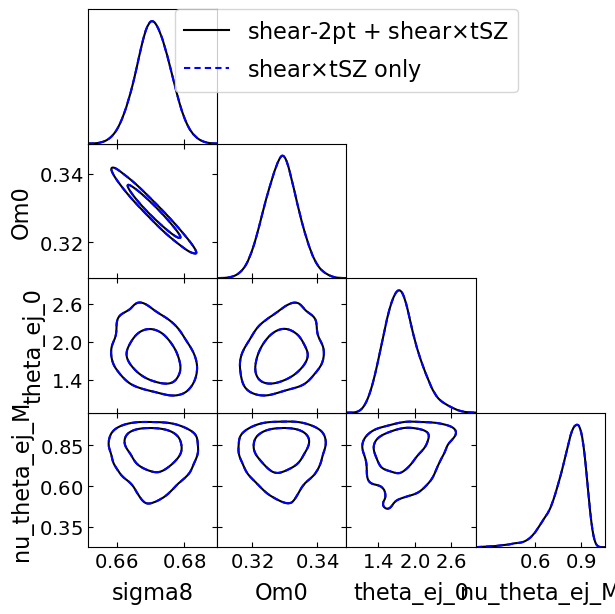

In [26]:
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M',  'nu_theta_ej_z',  'mu_beta','A_IA', 'eta_IA', 'sigma8', 'alpha_ky', 'S8']
# params = ['Om0','A_IA', 'eta_IA', 'sigma8',  'S8', 'h', 'ns', 'Ob0','mult_shear_bias_array_3',  'Delta_z_bias_array_3']
g = plots.getSinglePlotter(width_inch=6.25, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':1.0,'color':'black'},{'lw':1.0, 'ls':'--' ,'color':'blue'},{'lw':1.0,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}


# samps_all = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps_gty = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_gty_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps_xipm = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_xip_xim_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
params = samples.getParamNames().getRunningNames()
# g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot([samples, samples_np], ['sigma8', 'Om0', 'theta_ej_0', 'nu_theta_ej_M'], line_args=line_args, 
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''], legend_labels = [r'shear-2pt + shear$\times$tSZ',r'shear$\times$tSZ only',r'shear-2pt only'])
# save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# g.export(save_plot_dir  + 'contour_Om0_S8_nuejM_internal.pdf')
import matplotlib
%matplotlib inline
plt.show()






In [2]:
g = plots.get_subplot_plotter(width_inch=12)
g.triangle_plot([samples], filled=True)
# g.triangle_plot([samples], filled=True)




NameError: name 'plots' is not defined

In [ ]:
# all_data = ''
# for ji in range(2000):
#     all_data += f"{ji}\n"
# with open('/mnt/ceph/users/spandey/quijote_v2_gotham/GOTHAM/run_scripts_pm/all_LH.txt', 'w') as f:
#     f.write(all_data)


In [ ]:
import pickle as pk
import dill as dill
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os

import getdist
from getdist import plots, MCSamples




def get_MCsamps(fname, param_acorr='sigma8', acorr_min=0.0, acorr_max = 0.05, nchains = 96, ind_frac_rm = 0.1, names=None, labels=None):
    df = pk.load(open(fname,'rb'))
    sig8 = df[param_acorr]
    
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    from numpyro.diagnostics import autocorrelation, autocovariance
    
    acorr = autocorrelation(sig8_rs, axis=1)
    ind_del = []
    for ji in range(acorr.shape[0]):
        if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
            ind_del.append(ji)    
    
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    import getdist
    from getdist import plots, MCSamples
    
    if names is None:
        names = keys
        indsel_names = np.arange(len(names))
    else:
        indsel_names = []
        for name in names:
            indsel_names.append(keys.index(name))
    
    
    save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
    labels_all = {'A_IA':r'$A_{\rm IA}$',
     'Ob0':r'$\Omega_b$',
     'Om0':r'$\Omega_{\rm m}$',
     'eta_IA':r'$\eta_{\rm IA}$',
     'log10_Mc0':r'$\log(M_c)$',
     'theta_co_0':r'$\theta_{\rm co, 0}$',
     'gamma_rhogas':r'$\gamma$',
     'nu_z':r'$\nu_z$',
     'h':r'$h$',
     'ns':r'$n_s$',
     'mu_beta':r'$\mu_{\beta}$',
     'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
     'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
     'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
     'log10_Mc0':r'$\log(M_c)$',
        'delta_rhogas':r'$\delta$',
        'gamma_rhogas':r'$\gamma$',
     'sigma8':r'$\sigma_8$',
     'theta_ej_0':r'$\theta_{\rm ej, 0}$',
     'S8':r'$S_8$',
     'alpha_nt':r'$\alpha_{\rm nt}$',
     'alpha_ky':r'$\alpha_{\rm ky}$',
     'alpha_kk':r'$\alpha_{\rm kk}$',
    'Delta_z_bias_array_0':r'$\Delta z_1$',
     'Delta_z_bias_array_1':r'$\Delta z_2$',
     'Delta_z_bias_array_2':r'$\Delta z_3$',
     'Delta_z_bias_array_3':r'$\Delta z_4$',
     'mult_shear_bias_array_0':r'$m_1$',
     'mult_shear_bias_array_1':r'$m_2$',
     'mult_shear_bias_array_2':r'$m_3$',
     'mult_shear_bias_array_3':r'$m_4$'
    }
    
    if labels is None:
        labels = []
        
        for key in keys:
            if key in labels_all.keys():
                labels.append(labels_all[key])
            else:
                labels.append(r'm')
    
    
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    print(samps.shape, samps_sel.shape)
    from numpyro.diagnostics import gelman_rubin, effective_sample_size, print_summary
    ind_gr = ind_sigma8
    gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
    print(gr)
    
    samples = MCSamples(samples=samps[:,indsel_names],names = names, labels = labels)
    marge = samples.getMargeStats()
    # for j1 in range(len(names)):
        # paramj1 = names[j1]
        # r_marge = marge.parWithName(paramj1)
        # r_mean = r_marge.mean
        # print(paramj1 + ': ' + str(r_mean) + ', ' + str(r_mean - r_marge.limits[0].lower) + ', ' + str(r_marge.limits[0].upper -  r_mean))

    return samples




In [ ]:
# ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr/'
# samps_all = get_MCsamps(ldir + 'mcmc_v1_test.pkl')
# 
ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_july_v5'
probe= 'kk_gg_gk_ge'
lmax = 1000
samps_notSZ_8000 = get_MCsamps(f'{ldir}/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4.pkl')

probe= 'ky_kk_gg_gy_gk_ge'
lmax = 1000
samps_wtSZ_8000 = get_MCsamps(f'{ldir}/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4.pkl')




(111600, 29) (31, 3600, 29)
1.0258368813490104
Removed no burn in
(50400, 29) (14, 3600, 29)
1.0410630586800322
Removed no burn in


<Figure size 625x625 with 0 Axes>

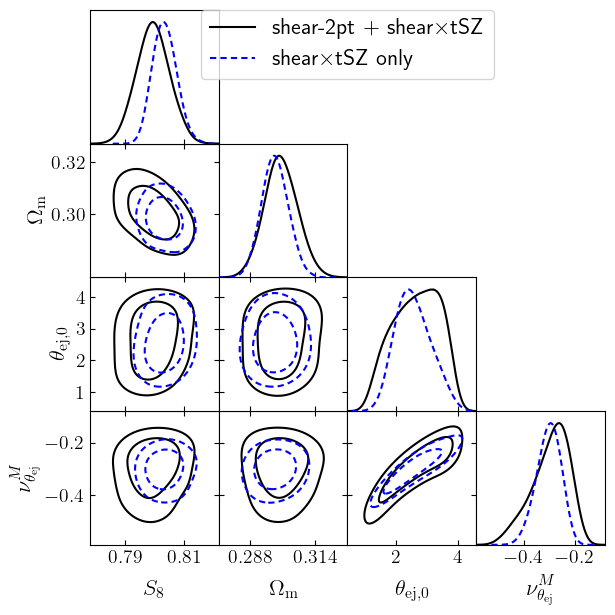

In [ ]:
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M',  'nu_theta_ej_z',  'mu_beta','A_IA', 'eta_IA', 'sigma8', 'alpha_ky', 'S8']
# params = ['Om0','A_IA', 'eta_IA', 'sigma8',  'S8', 'h', 'ns', 'Ob0','mult_shear_bias_array_3',  'Delta_z_bias_array_3']
g = plots.getSinglePlotter(width_inch=6.25, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':1.0,'color':'black'},{'lw':1.0, 'ls':'--' ,'color':'blue'},{'lw':1.0,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}


# samps_all = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps_gty = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_gty_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps_xipm = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_xip_xim_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
params = samps_all.getParamNames().getRunningNames()
# g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot([samps_notSZ_8000, samps_wtSZ_8000], ['S8', 'Om0', 'theta_ej_0', 'nu_theta_ej_M'], line_args=line_args, 
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''], legend_labels = [r'shear-2pt + shear$\times$tSZ',r'shear$\times$tSZ only',r'shear-2pt only'])
# save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# g.export(save_plot_dir  + 'contour_Om0_S8_nuejM_internal.pdf')
import matplotlib
%matplotlib inline
pl.show()



